In [67]:
import yfinance as yf
import pandas as pd
import seaborn as sns


In [68]:
btcTicker = yf.Ticker('BTC-USD')
btc = btcTicker.history(period="max")
btc.index = btc.index.tz_localize(None) #to remove timeZones
btc = btc.drop(columns=['Dividends','Stock Splits'])
btc.index = pd.to_datetime(btc.index)
btc

,Open,High,Low,Close,Volume
Date,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100
...,...,...,...,...,...
2025-03-27,86896.257812,87786.726562,85837.937500,87177.101562,24413471941
2025-03-28,87185.234375,87489.859375,83557.640625,84353.148438,34198619509
2025-03-29,84352.070312,84567.335938,81634.140625,82597.585938,16969396135


In [69]:
ethTicker = yf.Ticker('ETH-USD')
eth = ethTicker.history(period="max")
eth.index = eth.index.tz_localize(None) #to remove timeZones
eth = eth.drop(columns=['Dividends','Stock Splits'])
eth.index = pd.to_datetime(eth.index)
eth

,Open,High,Low,Close,Volume
Date,,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003,893249984
2017-11-10,320.670990,324.717987,294.541992,299.252991,885985984
2017-11-11,298.585999,319.453003,298.191986,314.681000,842300992
2017-11-12,314.690002,319.153015,298.513000,307.907990,1613479936
2017-11-13,307.024994,328.415009,307.024994,316.716003,1041889984
...,...,...,...,...,...
2025-03-27,2008.940552,2037.396118,1987.717773,2002.357422,11593274543
2025-03-28,2002.410522,2015.454346,1863.010620,1895.502930,18160526498
2025-03-29,1895.549683,1911.900879,1799.200806,1827.320312,12194771785


<Axes: xlabel='Date', ylabel='High'>

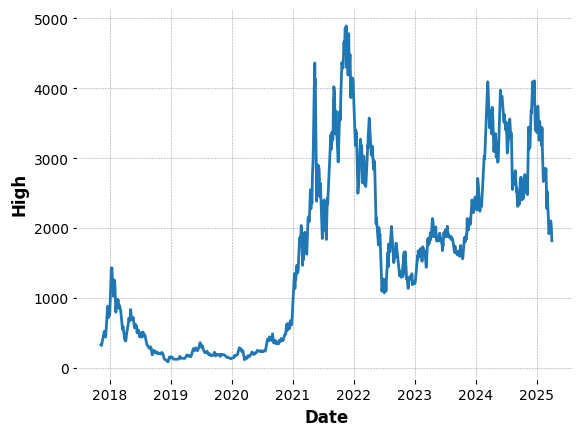

In [70]:
sns.lineplot(data=eth["High"])

<Axes: xlabel='Date', ylabel='High'>

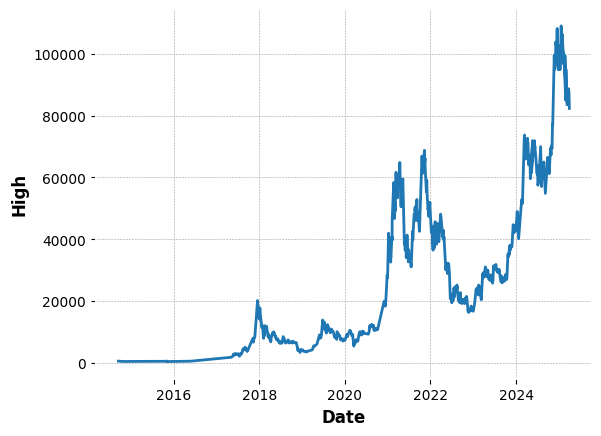

In [71]:
sns.lineplot(data=btc['High'])
# sns.lineplot(data=btc['Low'])
# sns.barplot(x = btc.index ,y = btc['Open'])
# sns.heatmap(data=btc,annot=True)

In [72]:
wikieth = pd.read_csv("/content/df_sent_eth_roll.csv",index_col=0,parse_dates=True)
wikieth

,edit_count,mean_sentiments,neg_sentiments,pos_sentiments
2014-02-25,0.066667,-0.066526,0.066667,0.000000
2014-02-26,0.033333,-0.033243,0.033333,0.000000
2014-02-27,0.033333,-0.033243,0.033333,0.000000
2014-02-28,0.033333,-0.033243,0.033333,0.000000
2014-03-01,0.033333,-0.033243,0.033333,0.000000
...,...,...,...,...
2025-03-27,0.533333,0.014642,0.071032,0.095635
2025-03-28,0.533333,0.014642,0.071032,0.095635
2025-03-29,0.566667,0.047848,0.071032,0.128968
2025-03-30,0.533333,0.022910,0.071032,0.095635


In [73]:
wikiBitcoin = pd.read_csv("/content/btc_sent_roll.csv",index_col=0,parse_dates=True)
wikiBitcoin

,edit_count,mean_sentiments,neg_sentiments,pos_sentiments
2009-04-06,0.133333,-0.018351,0.025,0.008333
2009-04-07,0.000000,0.000000,0.000,0.000000
2009-04-08,0.000000,0.000000,0.000,0.000000
2009-04-09,0.000000,0.000000,0.000,0.000000
2009-04-10,0.000000,0.000000,0.000,0.000000
...,...,...,...,...
2025-03-27,0.300000,-0.161421,0.200,0.033333
2025-03-28,0.300000,-0.161421,0.200,0.033333
2025-03-29,0.300000,-0.161421,0.200,0.033333
2025-03-30,0.300000,-0.161421,0.200,0.033333


In [74]:
btc = btc.merge(wikiBitcoin,left_index=True,right_index=True)
eth = eth.merge(wikieth,left_index=True,right_index=True)


In [75]:
btc

,Open,High,Low,Close,Volume,edit_count,mean_sentiments,neg_sentiments,pos_sentiments
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718,0.300615
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232760,0.532718,0.300615
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385,0.317282
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385,0.317282
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718,0.333948
...,...,...,...,...,...,...,...,...,...
2025-03-27,86896.257812,87786.726562,85837.937500,87177.101562,24413471941,0.300000,-0.161421,0.200000,0.033333
2025-03-28,87185.234375,87489.859375,83557.640625,84353.148438,34198619509,0.300000,-0.161421,0.200000,0.033333
2025-03-29,84352.070312,84567.335938,81634.140625,82597.585938,16969396135,0.300000,-0.161421,0.200000,0.033333
2025-03-30,82596.984375,83505.000000,81573.250000,82334.523438,14763760943,0.300000,-0.161421,0.200000,0.033333


In [76]:
eth

,Open,High,Low,Close,Volume,edit_count,mean_sentiments,neg_sentiments,pos_sentiments
2017-11-09,308.644989,329.451996,307.056000,320.884003,893249984,0.900000,-0.144123,0.261111,0.105556
2017-11-10,320.670990,324.717987,294.541992,299.252991,885985984,0.966667,-0.177429,0.294444,0.105556
2017-11-11,298.585999,319.453003,298.191986,314.681000,842300992,0.966667,-0.177429,0.294444,0.105556
2017-11-12,314.690002,319.153015,298.513000,307.907990,1613479936,0.966667,-0.177429,0.294444,0.105556
2017-11-13,307.024994,328.415009,307.024994,316.716003,1041889984,1.100000,-0.209260,0.327778,0.105556
...,...,...,...,...,...,...,...,...,...
2025-03-27,2008.940552,2037.396118,1987.717773,2002.357422,11593274543,0.533333,0.014642,0.071032,0.095635
2025-03-28,2002.410522,2015.454346,1863.010620,1895.502930,18160526498,0.533333,0.014642,0.071032,0.095635
2025-03-29,1895.549683,1911.900879,1799.200806,1827.320312,12194771785,0.566667,0.047848,0.071032,0.128968
2025-03-30,1827.311035,1847.570557,1769.412720,1806.218628,9854857162,0.533333,0.022910,0.071032,0.095635


In [77]:
btc["tomorrow"] = btc['Close'].shift(-1) #tommorows closing price
btc['target'] = (btc['tomorrow'] > btc['Close']).astype(int) #lets see the price of tomorrow will less or greater than todays price
print(f"BTC : {btc['target'].value_counts()}")

eth["tomorrow"] = eth['Close'].shift(-1) #tommorows closing price
eth['target'] = (eth['tomorrow'] > eth['Close']).astype(int) #lets see the price of tomorrow will less or greater than todays price
print(f"ETH : {eth['target'].value_counts()}")

BTC : target
1    2027
0    1822
Name: count, dtype: int64
ETH : target
1    1378
0    1322
Name: count, dtype: int64


In [78]:
# learning list comprehension
# a = [1,23,4,5]
# lt = [num for num in a if num >= 3]
# print(lt)

btc

,Open,High,Low,Close,Volume,edit_count,mean_sentiments,neg_sentiments,pos_sentiments,tomorrow,target
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718,0.300615,424.440002,0
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232760,0.532718,0.300615,394.795990,0
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385,0.317282,408.903992,1
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385,0.317282,398.821014,0
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718,0.333948,402.152008,1
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-27,86896.257812,87786.726562,85837.937500,87177.101562,24413471941,0.300000,-0.161421,0.200000,0.033333,84353.148438,0
2025-03-28,87185.234375,87489.859375,83557.640625,84353.148438,34198619509,0.300000,-0.161421,0.200000,0.033333,82597.585938,0
2025-03-29,84352.070312,84567.335938,81634.140625,82597.585938,16969396135,0.300000,-0.161421,0.200000,0.033333,82334.523438,0
2025-03-30,82596.984375,83505.000000,81573.250000,82334.523438,14763760943,0.300000,-0.161421,0.200000,0.033333,81849.351562,0


#Training baseline model  for testing

In [79]:
from sklearn.ensemble import RandomForestClassifier
BaselineModel = RandomForestClassifier(n_estimators=100,min_samples_split=50,random_state=1)

train_btc  = btc.iloc[:-200]
test_btc  = btc.iloc[-200:]
train_eth = eth.iloc[:-200]
test_eth  = eth.iloc[-200:]

x = ['Open'	,'High',	'Low',	'Close',	'Volume'	,'edit_count',	'mean_sentiments',	'neg_sentiments','pos_sentiments']
y=['target']
BaselineModel.fit(train_btc[y],train_btc['target'])

RandomForestClassifier(min_samples_split=50, random_state=1)

In [80]:
predictionsBM = BaselineModel.predict(test_btc[y])
predictionsBM

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0])

In [81]:
from sklearn.metrics import precision_score

precision_score(test_btc['target'],predictionsBM)

1.0

In [82]:
from xgboost import XGBClassifier

def xgbmodel(x_train,y_train,x_test,y_test):
  model = XGBClassifier(random_state=1, learning_rate=.001, n_estimators=300)
  model.fit(x_train,y_train)
  predictions = model.predict(x_test)
  score =  precision_score(y_test,predictions)
  # return score
  return predictions


In [83]:
btc_model_pre = xgbmodel(train_btc[x],train_btc[y],test_btc[x],test_btc[y])
eth_model_pre = xgbmodel(train_eth[x],train_eth[y],test_eth[x],test_eth[y])
# print(f'btc score : {btc_model}')
# print(f'eth score : {eth_model}')
btc_model_pre

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [84]:
predictionsdf_btc = pd.DataFrame()
predictionsdf_btc["prediction_btc"] = btc_model_pre
predictionsdf_btc.index = test_btc.index
predictionsdf_btc


,prediction_btc
2024-09-13,1
2024-09-14,1
2024-09-15,1
2024-09-16,1
2024-09-17,1
...,...
2025-03-27,0
2025-03-28,0
2025-03-29,0
2025-03-30,0


In [85]:
predictionsdf_eth = pd.DataFrame()
predictionsdf_eth["prediction_eth"] = eth_model_pre
predictionsdf_eth.index = test_eth.index
predictionsdf_eth

,prediction_eth
2024-09-13,0
2024-09-14,1
2024-09-15,0
2024-09-16,0
2024-09-17,0
...,...
2025-03-27,1
2025-03-28,1
2025-03-29,1
2025-03-30,1


In [86]:
btc_prediction = int(predictionsdf_btc['prediction_btc'].iloc[-1])
eth_prediction = int(predictionsdf_eth['prediction_eth'].iloc[-1])

if btc_prediction == 0:
  print("The btc price will be low compare to yesterday")
if btc_prediction == 1:
  print("The btc price will be higher compare to yesterday")
if eth_prediction == 0:
  print("The eth price will be low compare to yesterday")
if eth_prediction == 1:
  print("The eth price will be higher compare to yesterday")

The btc price will be low compare to yesterday
The eth price will be higher compare to yesterday


In [88]:
# !pip install mplfinance
# import mplfinance as mpf

# btc["Date"] = pd.to_datetime(btc.index)
# btc.set_index("Date", inplace=True)

# mpf.plot(btc.tail(100), type="candle", volume=True, style="charles", title="BTC Candlestick Chart")
